### Data Loading

In [371]:
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import entropy
import matplotlib.pyplot as plt
from tqdm import tqdm
import os

plt.style.use(
    #'../../Dataset-And-Solve-Class/class-12-ML-how-machine-learns/class-12-deeplearning.mplstyle' #my_windows
    '../Dataset-And-Solve-Class/class-12-ML-how-machine-learns/class-12-deeplearning.mplstyle' #mac
)

In [372]:
# Define paths
ROOT_DIR = ".." #mac
#ROOT_DIR = "../.." #my_windows
DATA_DIR = os.path.join(ROOT_DIR, "my-practice/Dataset")
DATASET_PATH = os.path.join(DATA_DIR, "housing.csv")

### Data Exploration and Visualization

In [373]:
dataset = pd.read_csv(DATASET_PATH)
dataset.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [374]:
dataset.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [375]:
numerical_cols = dataset.select_dtypes(include='number').columns
categorical_cols = dataset.select_dtypes(include='object').columns

print(numerical_cols)
print(categorical_cols)

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking'], dtype='object')
Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')


### Data Preprocessing

In [376]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
scaler = StandardScaler()
le = LabelEncoder()

In [377]:
dataset[numerical_cols] = scaler.fit_transform(dataset[numerical_cols])
dataset[numerical_cols].head()

,price,area,bedrooms,bathrooms,stories,parking
0,4.566365,1.046726,1.403419,1.421812,1.378217,1.517692
1,4.004484,1.757010,1.403419,5.405809,2.532024,2.679409
2,4.004484,2.218232,0.047278,1.421812,0.224410,1.517692
3,3.985755,1.083624,1.403419,1.421812,0.224410,2.679409
4,3.554979,1.046726,1.403419,-0.570187,0.224410,1.517692


In [378]:
dataset[categorical_cols] = dataset[categorical_cols].apply(
    le.fit_transform
)

dataset[categorical_cols].head()

,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus
0,1,0,0,0,1,1,0
1,1,0,0,0,1,0,0
2,1,0,1,0,0,1,1
3,1,0,1,0,1,1,0
4,1,1,1,0,1,0,0


### Feature Engineering

In [379]:
# Problem: From the housing dataset, we need to predict, the area in prefered or not [1 -> prefered, 0 -> not prefered]
target_var = 'prefarea'
dataset[target_var].value_counts()

prefarea
0    417
1    128
Name: count, dtype: int64

In [380]:
#select input [X], output [y]
X = dataset.drop(columns=target_var)
y = dataset[target_var]

In [381]:
X.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,furnishingstatus
0,4.566365,1.046726,1.403419,1.421812,1.378217,1,0,0,0,1,1.517692,0
1,4.004484,1.757010,1.403419,5.405809,2.532024,1,0,0,0,1,2.679409,0
2,4.004484,2.218232,0.047278,1.421812,0.224410,1,0,1,0,0,1.517692,1
3,3.985755,1.083624,1.403419,1.421812,0.224410,1,0,1,0,1,2.679409,0
4,3.554979,1.046726,1.403419,-0.570187,0.224410,1,1,1,0,1,1.517692,0


In [382]:
y.head()

0    1
1    0
2    1
3    1
4    0
Name: prefarea, dtype: int64

### Data Splitting Fairly and create Balanced dataset

In [383]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [384]:
y_train.value_counts()

prefarea
0    334
1    102
Name: count, dtype: int64

In [385]:
# as the dataset is imbalance, we will balance the dataset using any technique. We will follow oversamlpling SMOTE technique. It will increase lower value
# to reache upper value and create a balance dataset
from imblearn.over_sampling import SMOTE
smonte = SMOTE(random_state=42)
X_train, y_train = smonte.fit_resample(X_train, y_train) 

y_train.value_counts()

/Users/shajib/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


prefarea
0    334
1    334
Name: count, dtype: int64

# Model Selection

##### Decision Tree Classifier

In [386]:
# selecting decission tree classifier model
from sklearn.tree import DecisionTreeClassifier
decision_tree = DecisionTreeClassifier(random_state=42)

# train the model
decision_tree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [387]:
# see the prediction after training
y_pred = decision_tree.predict(X_test)
print(y_pred)

[0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 1 1 0 0 0 1 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0
 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 1 1 0 1 0 1
 0 0 1 0 1 0 0 1 1 1 1 0 0 1 1 0 0 0 0 1 0 1 0 0 0 1 0 0 0 0 1 0 0 0 1]


In [388]:
# now, we need to see how much accurate our prediction is
# sklearn.metrics - this package provide all the evaluation matrics

from sklearn.metrics import accuracy_score, classification_report
accuracy = accuracy_score(y_test, y_pred) #giving the real test output [y_test] and the our prediction [y_pred] using model
report = classification_report(y_test, y_pred) #same as above

In [389]:
print(accuracy)

0.7247706422018348


In [390]:
print(report)

              precision    recall  f1-score   support

           0       0.83      0.81      0.82        83
           1       0.43      0.46      0.44        26

    accuracy                           0.72       109
   macro avg       0.63      0.63      0.63       109
weighted avg       0.73      0.72      0.73       109



##### K-Nearest Neighbors (KNN)

In [391]:
#training on train data
from sklearn.neighbors import KNeighborsClassifier
neighbors = KNeighborsClassifier()
neighbors.fit(X_train, y_train)

KNeighborsClassifier()

In [392]:
#predict on test input data
y_pred = neighbors.predict(X_test)
print(y_pred)

[1 0 1 0 1 0 1 1 0 0 0 0 0 0 0 0 1 0 0 1 0 1 0 1 1 1 0 0 1 1 0 0 0 0 0 0 1
 0 0 0 1 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 0 0 1 1
 0 1 1 0 1 0 1 1 1 1 0 1 0 0 1 1 0 1 0 0 1 0 1 0 1 1 1 1 0 0 1 0 0 1 0]


In [393]:
# evaluation on test output vs predict
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

In [394]:
print(accuracy)

0.6238532110091743


In [395]:
print(report)

              precision    recall  f1-score   support

           0       0.83      0.64      0.72        83
           1       0.33      0.58      0.42        26

    accuracy                           0.62       109
   macro avg       0.58      0.61      0.57       109
weighted avg       0.71      0.62      0.65       109



##### Support Vector Classifier

In [396]:
from sklearn.svm import SVC
svm_model = SVC(probability=True, random_state=42)
svm_model.fit(X_train, y_train)

SVC(probability=True, random_state=42)

In [397]:
y_pred = svm_model.predict(X_test)
print(y_pred)

[0 0 0 1 0 1 1 0 0 0 0 0 0 0 0 0 1 1 0 0 0 1 0 1 1 1 0 0 0 1 0 0 0 0 0 0 1
 0 0 0 1 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 0 1 0 1 0 1
 0 0 1 0 1 0 0 1 0 1 0 1 0 1 1 0 0 1 0 0 0 0 0 0 1 1 0 0 1 0 1 0 0 1 0]


In [398]:
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(accuracy)

0.6697247706422018


In [399]:
print(report)

              precision    recall  f1-score   support

           0       0.81      0.73      0.77        83
           1       0.35      0.46      0.40        26

    accuracy                           0.67       109
   macro avg       0.58      0.60      0.59       109
weighted avg       0.70      0.67      0.68       109



# Ensemble Learning
এই অংশে আমরা ensemble model train, predict, evaluate এবং visualize করব।

##### Ensemble Evaluation Helper

In [400]:
from sklearn.ensemble import AdaBoostClassifier, BaggingClassifier, StackingClassifier, RandomForestClassifier, VotingClassifier  # ensemble learning model import করার জন্য
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score  # extra evaluation metric ও confusion matrix বের করার জন্য

ensemble_results = []  # সব ensemble model এর score এক জায়গায় জমা রাখার জন্য list নেওয়া হয়েছে

def evaluate_ensemble_model(model_name, y_test, y_pred):  # প্রতিটি ensemble model কে একই নিয়মে evaluate ও visualize করার জন্য function তৈরি করা হয়েছে
    y_test_series = pd.Series(y_test).reset_index(drop=True)  # actual test label কে নতুন index সহ series বানানো হয়েছে যাতে compare করা সহজ হয়
    y_pred_series = pd.Series(y_pred).reset_index(drop=True)  # predicted label কে নতুন index সহ series বানানো হয়েছে যাতে compare করা সহজ হয়
    accuracy = accuracy_score(y_test_series, y_pred_series)  # model এর overall accuracy মাপা হচ্ছে
    precision = precision_score(y_test_series, y_pred_series, zero_division=0)  # positive prediction কতটা সঠিক তা মাপা হচ্ছে
    recall = recall_score(y_test_series, y_pred_series, zero_division=0)  # actual positive এর কতগুলো model ধরতে পেরেছে তা মাপা হচ্ছে
    f1 = f1_score(y_test_series, y_pred_series, zero_division=0)  # precision ও recall এর balanced score বের করা হচ্ছে
    report = classification_report(y_test_series, y_pred_series, zero_division=0)  # class-wise বিস্তারিত performance report তৈরি করা হচ্ছে
    comparison_df = pd.DataFrame({  # actual আর predicted value পাশাপাশি দেখার জন্য dataframe বানানো হচ্ছে
        'y_test_actual': y_test_series,  # আসল test label এখানে রাখা হচ্ছে
        'y_predicted': y_pred_series  # model এর predicted label এখানে রাখা হচ্ছে
    })
    cm = confusion_matrix(y_test_series, y_pred_series)  # confusion matrix তৈরি করা হচ্ছে যাতে ভুল-সঠিক prediction বোঝা যায়
    ensemble_results.append({  # summary comparison এর জন্য metric list এ current model এর ফল রাখা হচ্ছে
        'Model': model_name,  # কোন model এর ফল তা store করা হচ্ছে
        'Accuracy': accuracy,  # accuracy score store করা হচ্ছে
        'Precision': precision,  # precision score store করা হচ্ছে
        'Recall': recall,  # recall score store করা হচ্ছে
        'F1 Score': f1  # f1 score store করা হচ্ছে
    })

    print(f'\n{model_name} Accuracy: {accuracy:.4f}')  # current model এর accuracy print করা হচ্ছে
    print(report)  # detailed classification report print করা হচ্ছে
    display(comparison_df.head(10))  # প্রথম ১০টি actual বনাম predicted row দেখানো হচ্ছে

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))  # একই figure এ ৩টি visualization বসানোর জন্য subplot তৈরি করা হচ্ছে

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])  # confusion matrix কে heatmap আকারে দেখানো হচ্ছে
    axes[0].set_title(f'{model_name} Confusion Matrix')  # confusion matrix plot এর title সেট করা হচ্ছে
    axes[0].set_xlabel('Predicted Label')  # x-axis এ predicted label এর নাম দেওয়া হচ্ছে
    axes[0].set_ylabel('Actual Label')  # y-axis এ actual label এর নাম দেওয়া হচ্ছে

    sample_df = comparison_df.head(25)  # প্রথম ২৫টি sample নিয়ে actual বনাম predicted curve দেখানোর জন্য data কাটা হচ্ছে
    axes[1].plot(sample_df.index, sample_df['y_test_actual'], marker='o', label='Actual')  # actual y_test কে line আকারে দেখানো হচ্ছে
    axes[1].plot(sample_df.index, sample_df['y_predicted'], marker='s', linestyle='--', label='Predicted')  # predicted y কে line আকারে দেখানো হচ্ছে
    axes[1].set_title(f'{model_name} y_test vs y_pred (First 25)')  # line plot এর title সেট করা হচ্ছে
    axes[1].set_xlabel('Sample Index')  # sample index কে x-axis নামে দেখানো হচ্ছে
    axes[1].set_ylabel('Class Label')  # class label কে y-axis নামে দেখানো হচ্ছে
    axes[1].legend()  # actual ও predicted line চেনার জন্য legend দেখানো হচ্ছে

    comparison_long_df = comparison_df.melt(var_name='Type', value_name='Class')  # count plot এ ব্যবহার করার জন্য dataframe long format এ নেওয়া হচ্ছে
    sns.countplot(data=comparison_long_df, x='Class', hue='Type', ax=axes[2])  # actual ও predicted class distribution বার চার্টে দেখানো হচ্ছে
    axes[2].set_title(f'{model_name} Actual vs Predicted Count')  # count plot এর title সেট করা হচ্ছে
    axes[2].set_xlabel('Class Label')  # class label কে x-axis নামে দেখানো হচ্ছে
    axes[2].set_ylabel('Count')  # sample count কে y-axis নামে দেখানো হচ্ছে

    plt.tight_layout()  # subplot গুলোর spacing সুন্দর করার জন্য layout adjust করা হচ্ছে
    plt.show()  # সব visualization একসাথে দেখানো হচ্ছে

    return comparison_df  # দরকার হলে actual বনাম predicted dataframe পরে ব্যবহার করার জন্য return করা হচ্ছে


##### Boosting

[0 0 0 1 0 1 1 0 0 0 0 0 0 0 0 0 1 1 0 0 0 1 0 0 0 1 0 0 0 0 0 1 0 0 0 1 0
 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 1 1 0 1 1 1
 0 0 1 0 1 0 1 1 1 1 1 0 0 1 0 0 0 0 0 1 0 1 0 0 0 1 0 1 0 0 1 0 0 0 1]

Boosting (AdaBoost) Accuracy: 0.6881
              precision    recall  f1-score   support

           0       0.82      0.76      0.79        83
           1       0.38      0.46      0.41        26

    accuracy                           0.69       109
   macro avg       0.60      0.61      0.60       109
weighted avg       0.71      0.69      0.70       109



,y_test_actual,y_predicted
0,0,0
1,1,0
2,0,0
3,0,1
4,0,0
5,0,1
6,0,1
7,1,0
8,0,0
9,0,0


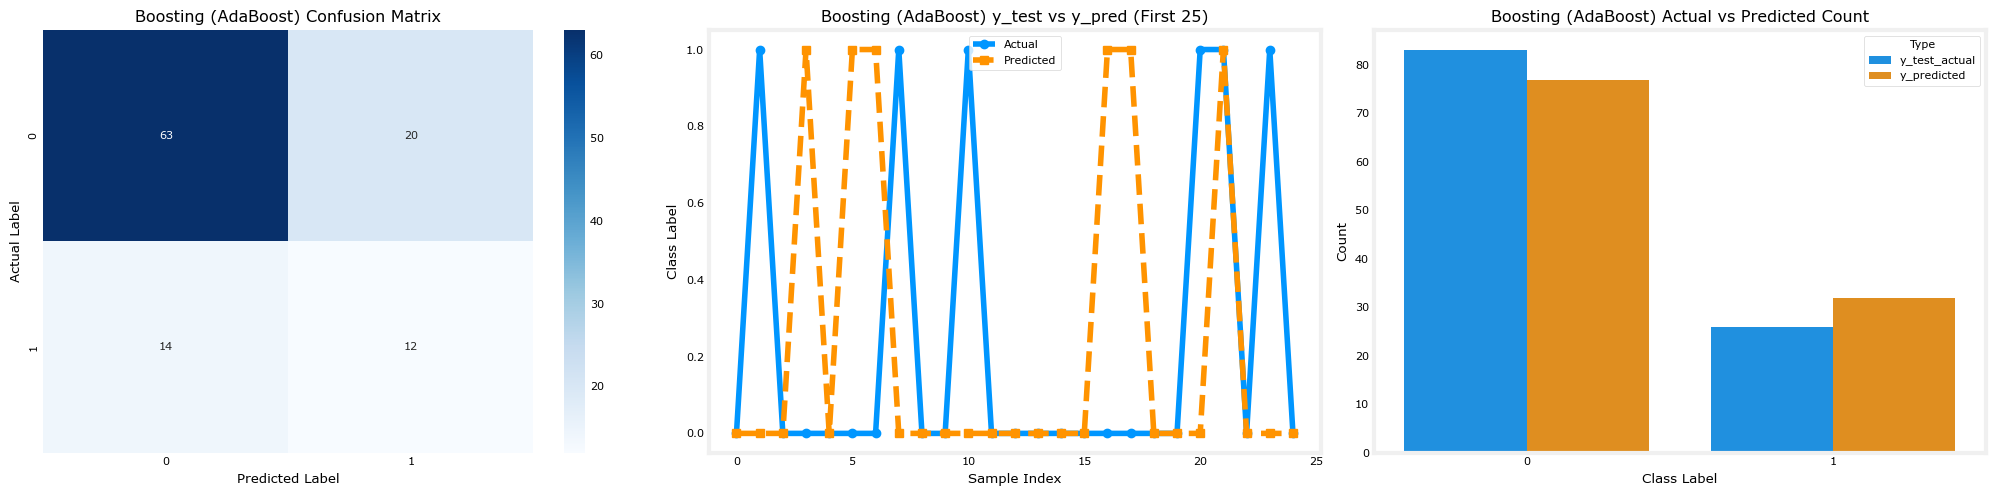

In [401]:
boosting_model = AdaBoostClassifier(  # boosting ensemble model তৈরি করা হচ্ছে
    estimator=DecisionTreeClassifier(random_state=42),  # base learner হিসেবে decision tree ব্যবহার করা হচ্ছে
    n_estimators=3,  # sequential ভাবে ৩টি weak learner train করা হবে
    random_state=42  # একই result পাওয়ার জন্য random seed fix করা হয়েছে
)
boosting_model.fit(X_train, y_train)  # train data ব্যবহার করে boosting model train করা হচ্ছে
boosting_y_pred = boosting_model.predict(X_test)  # test data এর জন্য prediction নেওয়া হচ্ছে
print(boosting_y_pred)  # raw prediction array দেখা হচ্ছে
boosting_comparison_df = evaluate_ensemble_model('Boosting (AdaBoost)', y_test, boosting_y_pred)  # evaluation report ও visualization একসাথে চালানো হচ্ছে


### Bagging

[0 1 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 1 1 0 1 0 0
 0 0 1 0 0 0 0 0 1 1 0 1 0 1 1 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 1]

Bagging Accuracy: 0.7706
              precision    recall  f1-score   support

           0       0.83      0.88      0.85        83
           1       0.52      0.42      0.47        26

    accuracy                           0.77       109
   macro avg       0.68      0.65      0.66       109
weighted avg       0.76      0.77      0.76       109



,y_test_actual,y_predicted
0,0,0
1,1,1
2,0,0
3,0,0
4,0,0
5,0,1
6,0,1
7,1,0
8,0,0
9,0,0


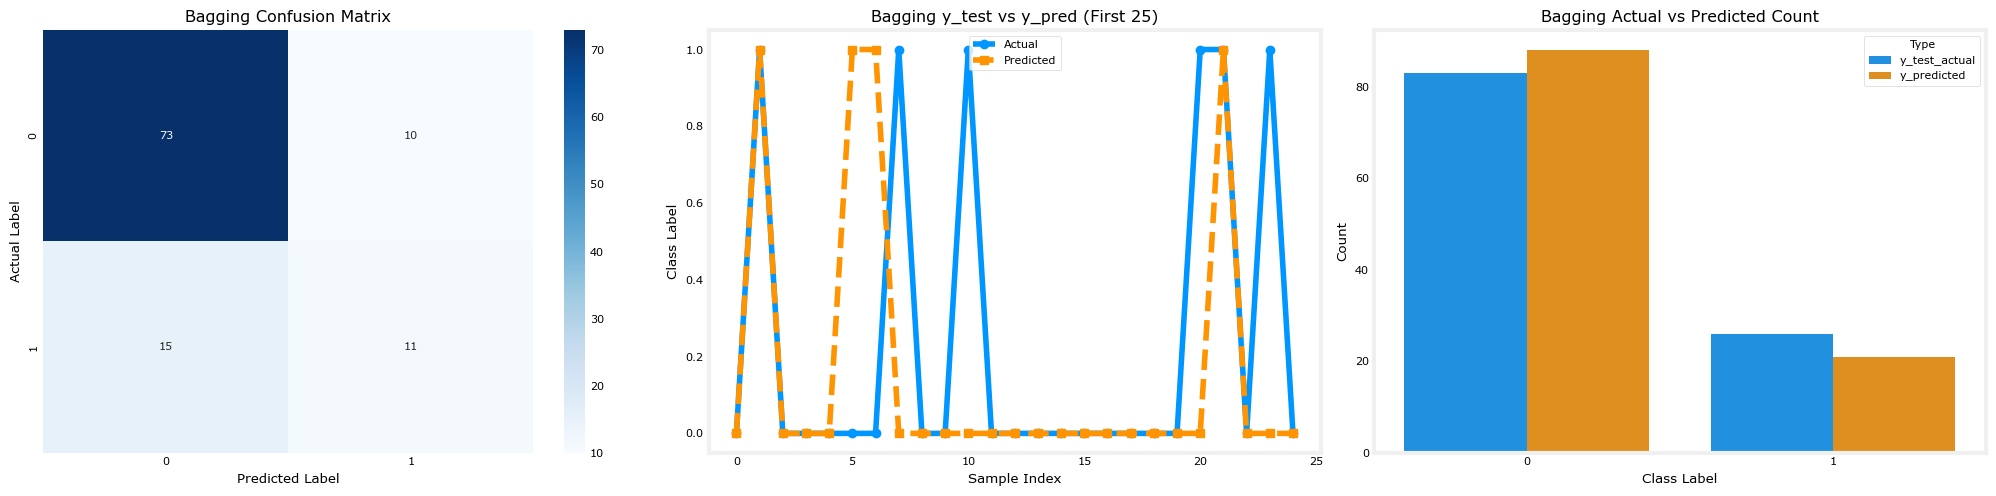

In [402]:
bagging_model = BaggingClassifier(  # bagging ensemble model তৈরি করা হচ্ছে
    estimator=DecisionTreeClassifier(random_state=42),  # base learner হিসেবে decision tree নেওয়া হয়েছে
    n_estimators=10,  # ১০টি আলাদা bootstrap model train করা হবে
    random_state=42  # result reproducible রাখার জন্য random seed fix করা হয়েছে
)
bagging_model.fit(X_train, y_train)  # train data দিয়ে bagging model fit করা হচ্ছে
bagging_y_pred = bagging_model.predict(X_test)  # test data এর prediction নেওয়া হচ্ছে
print(bagging_y_pred)  # raw prediction array print করা হচ্ছে
bagging_comparison_df = evaluate_ensemble_model('Bagging', y_test, bagging_y_pred)  # bagging model এর evaluation ও visualization দেখানো হচ্ছে


### Stacking

[1 0 0 1 0 0 1 1 0 1 0 0 0 0 0 0 0 1 0 1 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0
 0 0 1 1 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 1 0 1 0 1
 0 0 1 0 1 0 0 1 0 1 0 0 0 1 1 1 0 1 0 0 0 0 0 0 0 1 1 0 0 0 1 1 0 0 0]

Stacking Accuracy: 0.6514
              precision    recall  f1-score   support

           0       0.78      0.75      0.77        83
           1       0.30      0.35      0.32        26

    accuracy                           0.65       109
   macro avg       0.54      0.55      0.54       109
weighted avg       0.67      0.65      0.66       109



,y_test_actual,y_predicted
0,0,1
1,1,0
2,0,0
3,0,1
4,0,0
5,0,0
6,0,1
7,1,1
8,0,0
9,0,1


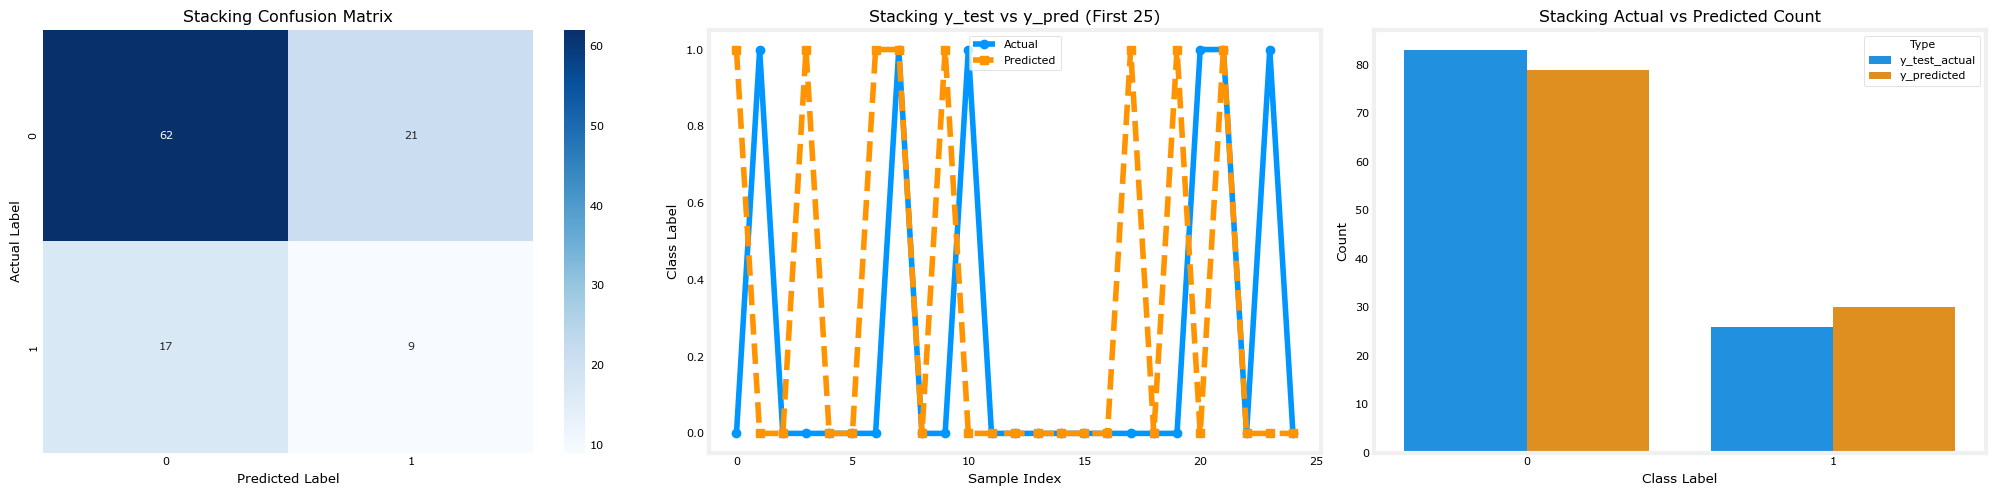

In [403]:
stacking_estimators = [  # stacking model এর base estimator list তৈরি করা হচ্ছে
    ('decision_tree', DecisionTreeClassifier(random_state=42)),  # প্রথম base model হিসেবে decision tree নেওয়া হয়েছে
    ('knn', KNeighborsClassifier()),  # দ্বিতীয় base model হিসেবে KNN নেওয়া হয়েছে
    ('svm', SVC(probability=True, random_state=42))  # তৃতীয় base model হিসেবে probability-enabled SVM নেওয়া হয়েছে
]
stacking_model = StackingClassifier(  # stacking ensemble model তৈরি করা হচ্ছে
    estimators=stacking_estimators,  # base estimator list model এ দেওয়া হচ্ছে
    final_estimator=RandomForestClassifier(random_state=42)  # meta learner হিসেবে random forest ব্যবহার করা হচ্ছে
)
stacking_model.fit(X_train, y_train)  # training data ব্যবহার করে stacking model fit করা হচ্ছে
stacking_y_pred = stacking_model.predict(X_test)  # test data এর prediction নেওয়া হচ্ছে
print(stacking_y_pred)  # raw prediction array print করা হচ্ছে
stacking_comparison_df = evaluate_ensemble_model('Stacking', y_test, stacking_y_pred)  # stacking model এর evaluation ও visualization দেখানো হচ্ছে


### Voting

[0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 1 1 0 0 0 1 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0
 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 1 1 0 1 0 1
 0 0 1 0 1 0 0 1 1 1 0 0 0 1 1 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 1]

Voting Accuracy: 0.7431
              precision    recall  f1-score   support

           0       0.83      0.83      0.83        83
           1       0.46      0.46      0.46        26

    accuracy                           0.74       109
   macro avg       0.65      0.65      0.65       109
weighted avg       0.74      0.74      0.74       109



,y_test_actual,y_predicted
0,0,0
1,1,0
2,0,0
3,0,1
4,0,0
5,0,0
6,0,1
7,1,0
8,0,0
9,0,0


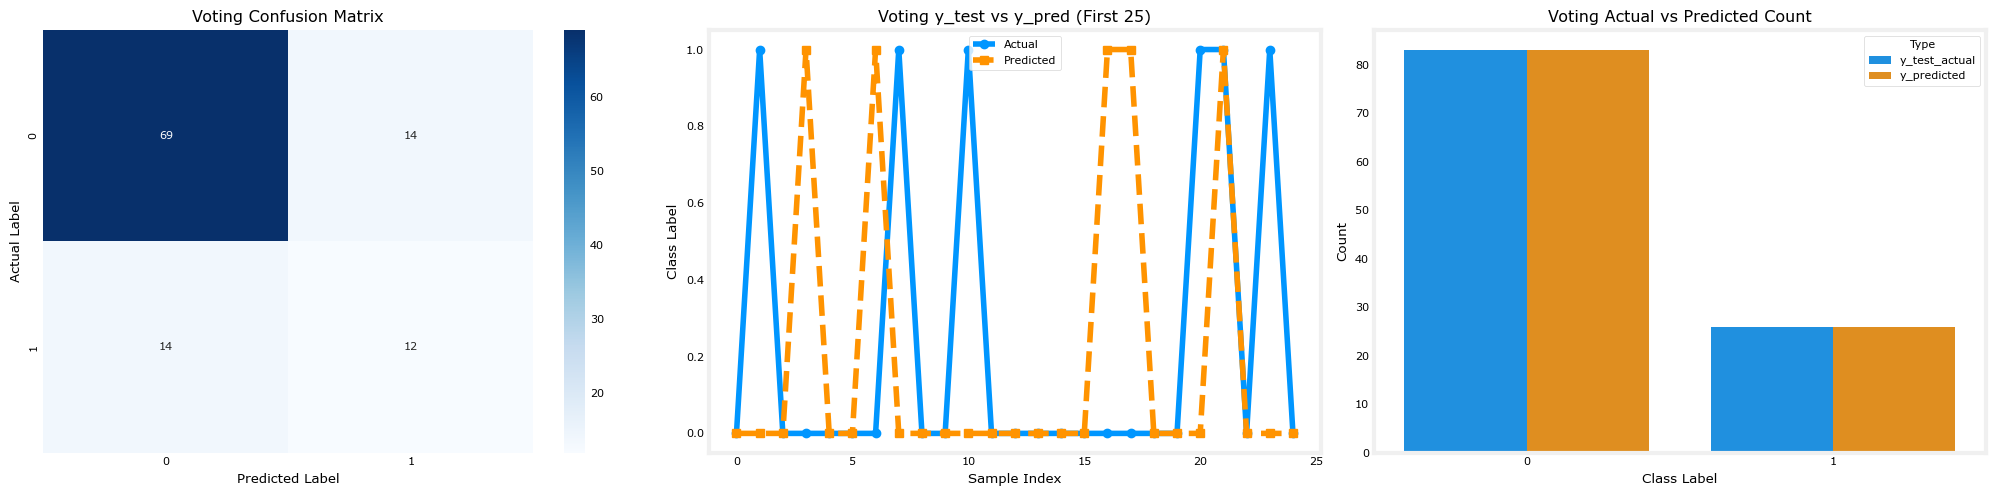

In [404]:
voting_estimators = [  # voting model এর জন্য base estimator list তৈরি করা হচ্ছে
    ('decision_tree', DecisionTreeClassifier(random_state=42)),  # প্রথম ভোটদাতা model হিসেবে decision tree নেওয়া হয়েছে
    ('knn', KNeighborsClassifier()),  # দ্বিতীয় ভোটদাতা model হিসেবে KNN নেওয়া হয়েছে
    ('svm', SVC(probability=True, random_state=42))  # তৃতীয় ভোটদাতা model হিসেবে SVM নেওয়া হয়েছে
]
votting_model = VotingClassifier(  # soft voting ensemble model তৈরি করা হচ্ছে
    estimators=voting_estimators,  # base estimator list model এ দেওয়া হচ্ছে
    voting='soft'  # probability score এর ভিত্তিতে final vote নেওয়া হবে
)
votting_model.fit(X_train, y_train)  # training data ব্যবহার করে voting model fit করা হচ্ছে
votting_y_pred = votting_model.predict(X_test)  # test data এর prediction voting model থেকে নেওয়া হচ্ছে
print(votting_y_pred)  # raw prediction array print করা হচ্ছে
votting_comparison_df = evaluate_ensemble_model('Voting', y_test, votting_y_pred)  # voting model এর evaluation ও visualization দেখানো হচ্ছে


### Ensemble Result Summary

,Model,Accuracy,Precision,Recall,F1 Score
0,Bagging,0.770642,0.523810,0.423077,0.468085
1,Voting,0.743119,0.461538,0.461538,0.461538
2,Boosting (AdaBoost),0.688073,0.375000,0.461538,0.413793
3,Stacking,0.651376,0.300000,0.346154,0.321429


/var/folders/pn/8ycqdd292xlcd63rv2zz74cc0000gp/T/ipykernel_2732/2881409287.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ensemble_summary_df, x='Model', y='Accuracy', palette='viridis')  # সব ensemble model এর accuracy bar chart এ দেখানো হচ্ছে


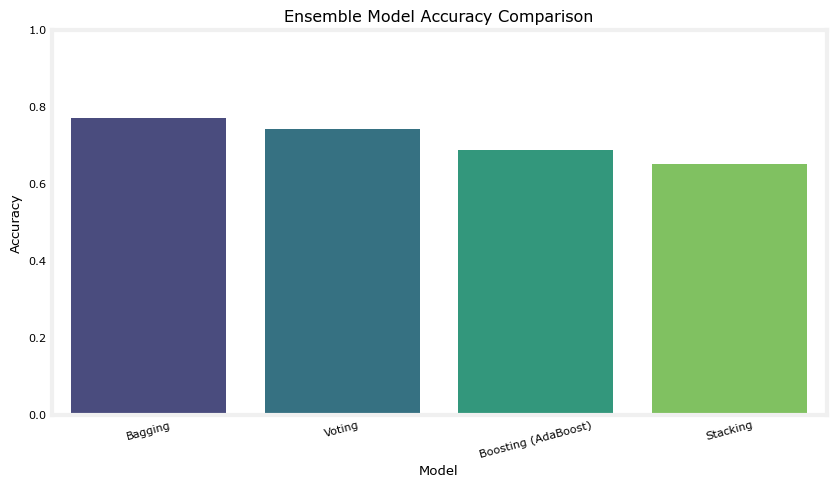

In [405]:
ensemble_summary_df = pd.DataFrame(ensemble_results)  # সব ensemble model এর metric নিয়ে summary dataframe বানানো হচ্ছে
ensemble_summary_df = ensemble_summary_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)  # accuracy অনুযায়ী model গুলো sort করা হচ্ছে
display(ensemble_summary_df)  # summary table notebook এ দেখানো হচ্ছে

plt.figure(figsize=(10, 5))  # comparison bar chart আঁকার জন্য figure size ঠিক করা হচ্ছে
sns.barplot(data=ensemble_summary_df, x='Model', y='Accuracy', palette='viridis')  # সব ensemble model এর accuracy bar chart এ দেখানো হচ্ছে
plt.title('Ensemble Model Accuracy Comparison')  # plot এর title সেট করা হচ্ছে
plt.ylim(0, 1)  # accuracy scale ০ থেকে ১ এর মধ্যে সীমাবদ্ধ রাখা হচ্ছে
plt.xticks(rotation=15)  # model name overlap এড়াতে text সামান্য rotate করা হচ্ছে
plt.show()  # final comparison chart দেখানো হচ্ছে


## README: Ensemble Learning Practice (বাংলা)

এই notebook-এ তুমি housing dataset ব্যবহার করে classification problem solve করেছ, যেখানে `prefarea` target variable predict করা হয়েছে। নিচে পুরো practice-এ cover করা topic-গুলো **Data**, **Model**, এবং **Training** এই ৩টি ভাগে সাজানো হলো।

### 1. Data অংশ
**যে টপিকগুলো cover করা হয়েছে:**
- dataset load করা (`pandas.read_csv`)
- numerical এবং categorical feature আলাদা করা
- standardization করা (`StandardScaler`)
- categorical encoding করা (`LabelEncoder`)
- target variable select করা (`prefarea`)
- feature matrix `X` এবং target `y` তৈরি করা
- train-test split করা
- imbalance সমস্যা সমাধানে `SMOTE` দিয়ে oversampling করা

**এখানে কী শিখেছ:**
- raw data সরাসরি model-এ না দিয়ে আগে preprocess করতে হয়
- numerical data scale করলে distance-based model যেমন KNN এবং margin-based model যেমন SVM ভালো কাজ করতে পারে
- categorical text data model বোঝে না, তাই encoding দরকার হয়
- imbalance dataset থাকলে model majority class এর দিকে bias হতে পারে, তাই balancing দরকার

**Improvement ideas:**
- missing value check আরও explicitly করা যেতে পারে
- outlier visualization (boxplot/histogram) যোগ করা যেতে পারে
- `Pipeline` ব্যবহার করলে preprocessing + model training একসাথে clean ভাবে করা যেত
- `train_test_split(..., stratify=y)` ব্যবহার করলে class ratio আরও fair রাখা যেত

### 2. Model অংশ
**যে টপিকগুলো cover করা হয়েছে:**
- Decision Tree Classifier
- K-Nearest Neighbors (KNN)
- Support Vector Classifier (SVC)
- AdaBoost / Boosting
- Bagging
- Stacking
- Soft Voting

**এখানে কী শিখেছ:**
- single model আর ensemble model-এর মধ্যে পার্থক্য
- boosting sequential ভাবে weak learner improve করে
- bagging random sample নিয়ে একাধিক model train করে variance কমায়
- stacking base model-এর output ব্যবহার করে meta model train করে
- voting একাধিক model-এর decision combine করে final result দেয়

**Improvement ideas:**
- base model-এর hyperparameter tuning করা যেতে পারে
- `GradientBoosting`, `RandomForest`, `XGBoost`, `LightGBM` এর মতো আরও ensemble model practice করা যেতে পারে
- feature importance বের করলে কোন feature বেশি useful তা বোঝা সহজ হতো
- probabilistic threshold tuning করলে class-1 recall improve হতে পারে

### 3. Training অংশ
**যে টপিকগুলো cover করা হয়েছে:**
- model fit করা (`fit`)
- prediction নেওয়া (`predict`)
- accuracy score বের করা
- classification report দেখা
- confusion matrix visualization
- actual `y_test` vs predicted `y_pred` curve দেখা
- ensemble model summary comparison plot তৈরি করা

**এখানে কী শিখেছ:**
- শুধু accuracy দেখলেই যথেষ্ট নয়
- precision, recall, f1-score class imbalance problem এ বেশি useful
- confusion matrix model কোথায় ভুল করছে সেটা বুঝতে সাহায্য করে
- `y_test` vs `y_pred` plot দিয়ে sample-wise prediction behaviour দেখা যায়
- multiple ensemble model compare করলে কোনটা ভালো করছে তা দ্রুত বোঝা যায়

**Improvement ideas:**
- cross-validation যোগ করলে evaluation আরও robust হতো
- ROC curve এবং AUC score যোগ করা যেতে পারে
- precision-recall curve minority class analysis-এ useful হতে পারে
- class-wise error analysis করলে false positive/false negative আলাদা করে বোঝা যেত

### ML Topics List
- Data loading
- Data preprocessing
- Feature scaling
- Label encoding
- Target selection
- Train-test split
- Imbalanced data handling with SMOTE
- Classification
- Decision Tree
- KNN
- SVM
- Ensemble learning
- Boosting
- Bagging
- Stacking
- Voting
- Prediction
- Accuracy
- Precision / Recall / F1-score
- Confusion matrix
- Visualization

### ছোট ভিজ্যুয়াল উদাহরণ
```text
Raw Data -> Preprocessing -> Train/Test Split -> SMOTE -> Model Fit -> Predict -> Evaluate -> Visualize

Boosting : Tree-1 -> ভুল sample-এ বেশি focus -> Tree-2 -> আরও improve -> Final prediction
Bagging  : Sample-1 -> Tree-1
           Sample-2 -> Tree-2
           Sample-3 -> Tree-3 -> Average / Vote
Stacking : Base models -> predictions -> Meta model -> Final prediction
Voting   : Model-1 vote + Model-2 vote + Model-3 vote -> Final vote
```

### সংক্ষিপ্ত উপসংহার
এই notebook-এ তুমি শুধু model train করনি, বরং data preprocessing থেকে শুরু করে ensemble learning model compare করা, evaluation report দেখা, confusion matrix ও `y_test` vs `y_pred` visualization পর্যন্ত একটি end-to-end ML workflow practice করেছ। Ensemble অংশে visualization যোগ হওয়ায় এখন model-এর behaviour আরও পরিষ্কারভাবে বোঝা যাবে।
